In [64]:
!pip install -q gensim scikit-learn pandas matplotlib

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gensim.models import Word2Vec

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import ast

df = pd.read_csv(
    "gutenberg_books.csv",
    dtype={"book_id": str}
)

df["tokens"] = df["tokens_clean"].apply(ast.literal_eval)

sentencas = df["tokens"].tolist()

quantidade_palavras = sum(
    len(sentenca)
    for sentenca in sentencas
)

modelo = Word2Vec(
    sentences=sentencas,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20
)

In [66]:
# palavras semelhantes
modelo.wv.most_similar("religion", topn=10)

[('faith', 0.734859049320221),
 ('religious', 0.71761155128479),
 ('doctrines', 0.7138293385505676),
 ('agnosticism', 0.7050496339797974),
 ('infallibility', 0.6920299530029297),
 ('rootless', 0.6834371089935303),
 ('pusillanimous', 0.6798707842826843),
 ('self-knowledge', 0.6797935962677002),
 ('discerned.', 0.6763665080070496),
 ('christian', 0.6755711436271667)]

In [67]:
# similiradidade entre as duas palavras
modelo.wv.similarity(
    "politics",
    "religion"
)

np.float32(0.5369443)

In [68]:
def vetor_livro(tokens, modelo):

    vetores = []

    for palavra in tokens:

        if palavra in modelo.wv:
            vetores.append(
                modelo.wv[palavra]
            )

    if len(vetores) == 0:
        return np.zeros(
            modelo.vector_size
        )

    return np.mean(
        vetores,
        axis=0
    )

embeddings = np.array([
    vetor_livro(tokens, modelo)
    for tokens in sentencas
])

print("Formato dos embeddings:", embeddings.shape)

Formato dos embeddings: (312, 100)


In [69]:
resultados_k = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        embeddings
    )

    score = silhouette_score(
        embeddings,
        labels
    )

    resultados_k.append({
        "k": k,
        "silhouette": score
    })

resultados_k = pd.DataFrame(
    resultados_k
)

resultados_k

,k,silhouette
0,2,0.246499
1,3,0.146380
2,4,0.132419
3,5,0.117032
4,6,0.130726
5,7,0.131185
6,8,0.113180
7,9,0.122425
8,10,0.120400


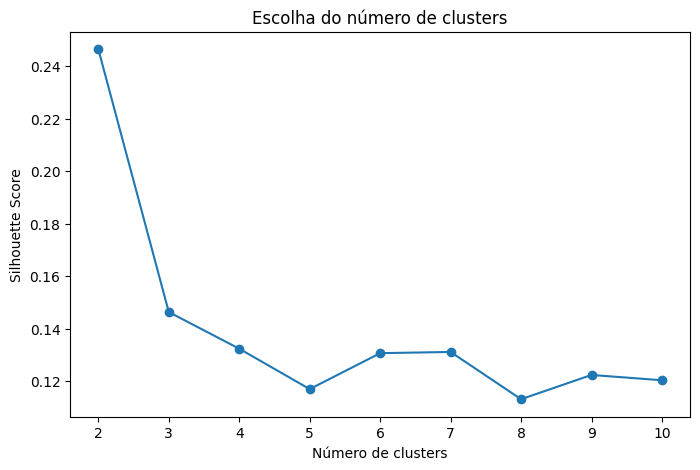

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultados_k["k"],
    resultados_k["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Escolha do número de clusters")

plt.show()

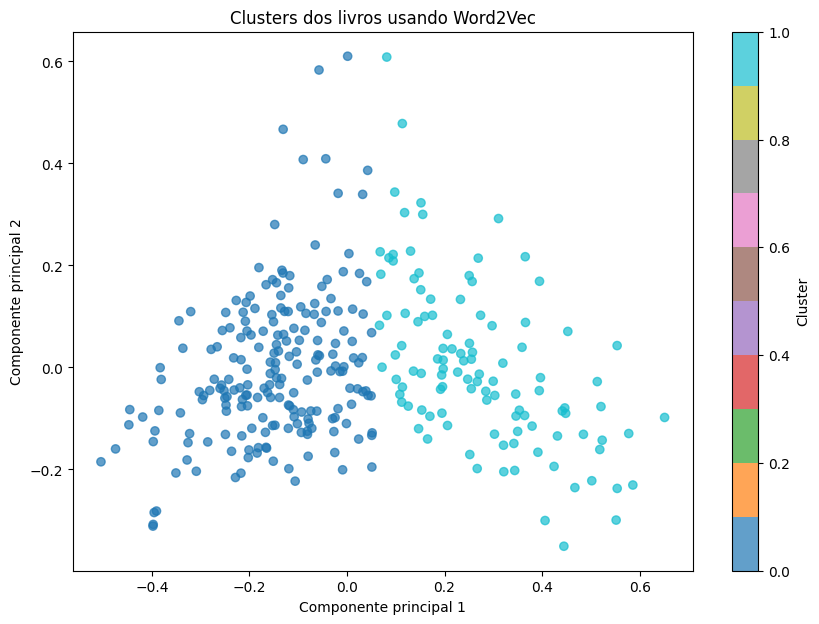

In [78]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    embeddings
)

df["cluster"] = clusters

pca = PCA(
    n_components=2
)

embeddings_2d = pca.fit_transform(
    embeddings
)

plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters dos livros usando Word2Vec")

plt.colorbar(
    label="Cluster"
)

plt.show()

In [79]:
def vetor_consulta(
    consulta,
    modelo
):

    tokens = consulta.split()

    return vetor_livro(
        tokens,
        modelo
    )

def buscar(
    consulta,
    quantidade=10
):

    vetor = vetor_consulta(
        consulta,
        modelo
    )

    similaridades = cosine_similarity(
        [vetor],
        embeddings
    ).flatten()

    indices = (
        similaridades
        .argsort()[::-1]
    )

    resultados = df.iloc[
        indices[:quantidade]
    ].copy()

    resultados["similaridade"] = (
        similaridades[
            indices[:quantidade]
        ]
    )

    return resultados

In [82]:
resultados = buscar(
    "war politics",
    quantidade=10
)

resultados[
    [
        "book_id",
        "cluster",
        "similaridade"
    ]
]

,book_id,cluster,similaridade
133,816,1,0.672598
251,712,1,0.669974
146,1946,1,0.667103
105,1804,1,0.662916
282,2373,1,0.662333
286,1689,1,0.660043
302,1713,1,0.659960
276,1335,1,0.655629
182,1187,1,0.654545
132,2173,1,0.654130


In [81]:
resultados = buscar(
    "religion morality",
    quantidade=10
)

resultados[
    [
        "book_id",
        "cluster",
        "similaridade"
    ]
]

,book_id,cluster,similaridade
277,1911,1,0.690867
286,1689,1,0.686194
282,2373,1,0.676656
133,816,1,0.671608
37,1566,1,0.657247
77,2330,1,0.655860
98,608,1,0.654972
86,908,1,0.654846
276,1335,1,0.653680
132,2173,1,0.649914
